In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [69]:
#READ AND LOAD DATASET

data = pd.read_csv("advertising.csv")

#clean columns
data.columns = data.columns.str.strip()
print(data.head(10))

      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
5    8.7   48.9       75.0    7.2
6   57.5   32.8       23.5   11.8
7  120.2   19.6       11.6   13.2
8    8.6    2.1        1.0    4.8
9  199.8    2.6       21.2   10.6


In [71]:
#FEATURES
X = data[['TV', 'radio', 'newspaper']]
y = data['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [73]:
#TRAIN MODEL 

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [75]:
#prediction
y_pred = model.predict(X_test)

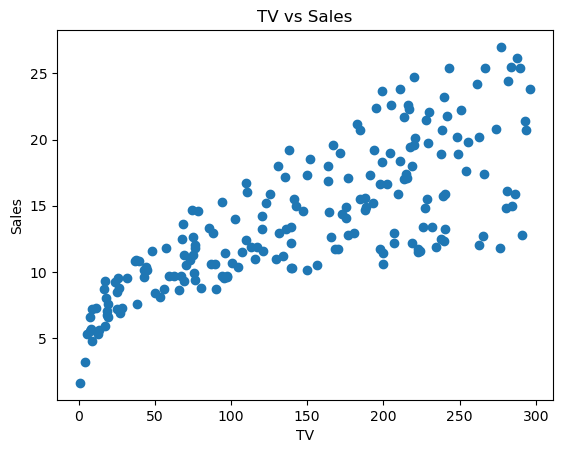

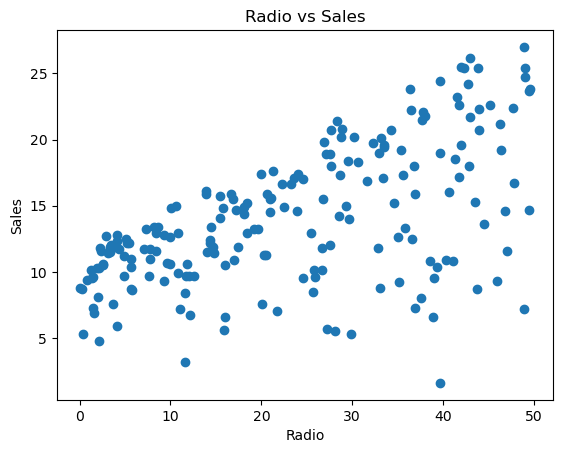

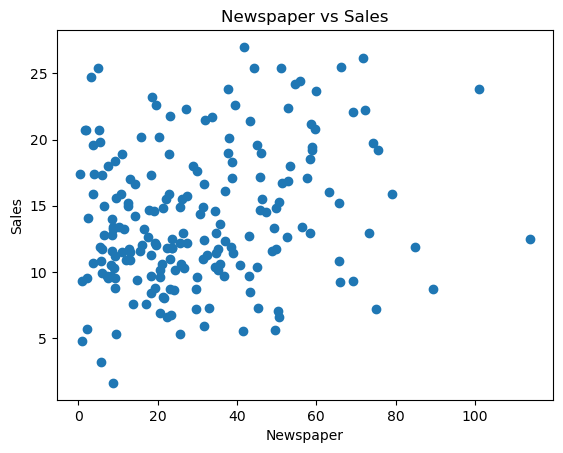

In [77]:
plt.scatter(data['TV'], data['sales'])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

plt.scatter(data['radio'], data['sales'])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

plt.scatter(data['newspaper'], data['sales'])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

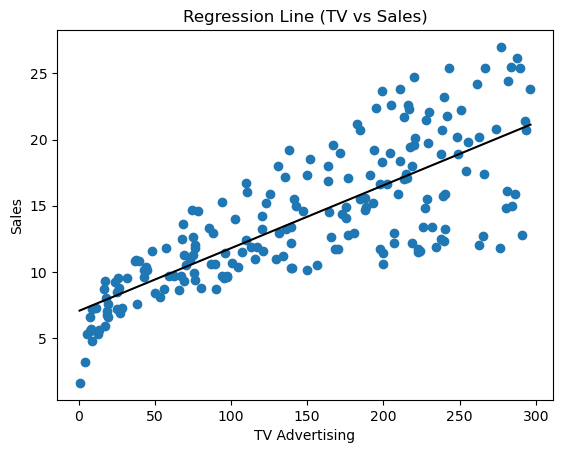

In [99]:
#USING ONLY TV FOR VISUALIZATION

X_tv = data[['TV']]
y_tv = data['sales']

model_tv = LinearRegression()
model_tv.fit(X_tv, y_tv)

y_tv_pred = model_tv.predict(X_tv)

# Sort for clean line
sorted_idx = np.argsort(data['TV'])
X_sorted = data['TV'].values[sorted_idx]
y_sorted = y_tv_pred[sorted_idx]

plt.scatter(data['TV'], data['sales'])
plt.plot(X_sorted, y_sorted, color = 'black')

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Regression Line (TV vs Sales)")
plt.show()

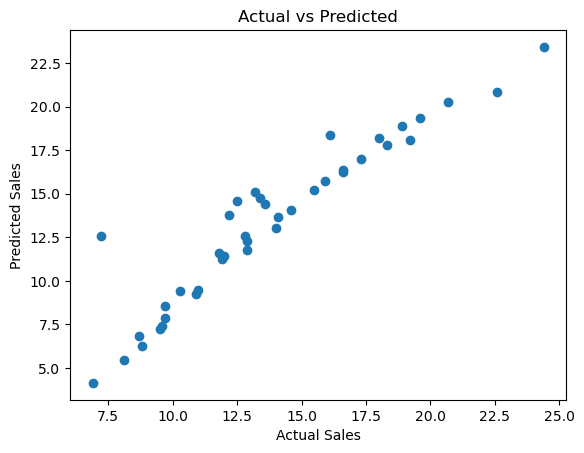

In [83]:
#Actual vs Predicted

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.show()

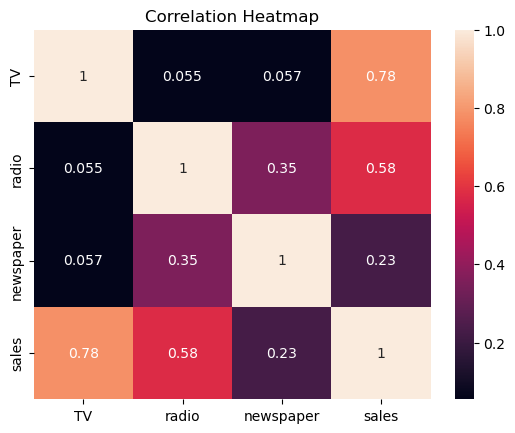

In [85]:
#HEATMAP

sns.heatmap(data.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

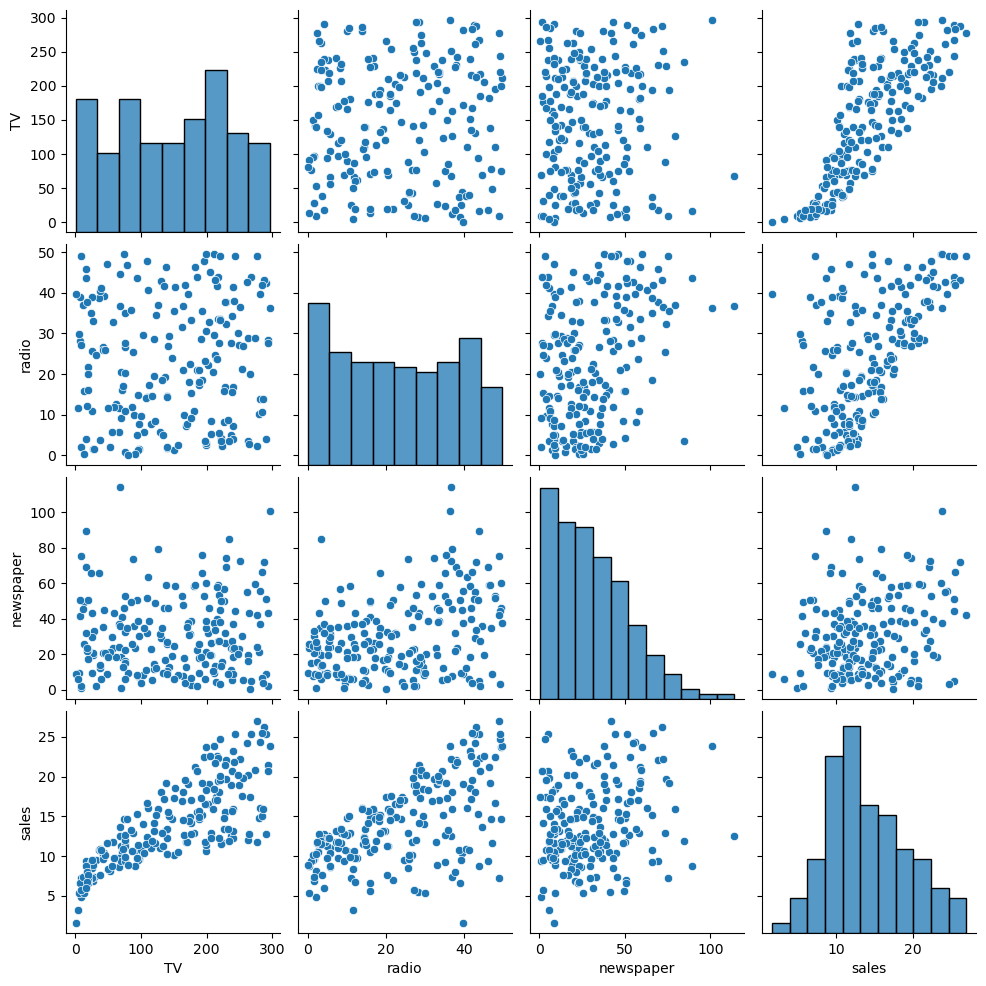

In [87]:
#PAIR PLOT

sns.pairplot(data)
plt.show()

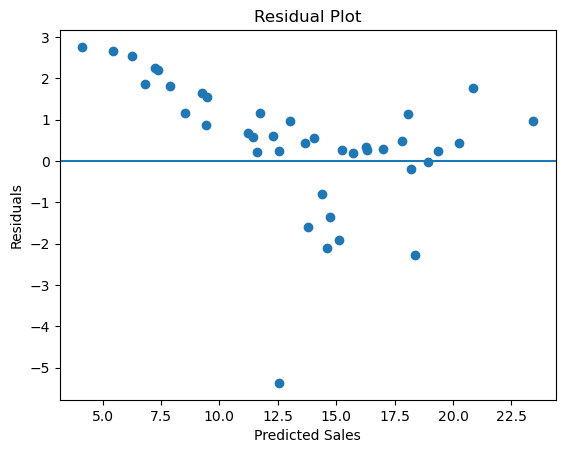

In [89]:
#RESIDUAL PLOT

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.show()

In [91]:
#Evaluate Model
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))

MSE: 2.568852796198113
R2 score: 0.8524919439449834
